# Entrenamiento — Fase B: Detección Preventiva de Stress (v2)

## Mejoras aplicadas respecto a v1

| # | Problema | Solución |
|---|----------|----------|
| 1 | `dist_to_onset` faltaba en el `.npz` | Ahora se guarda junto a cada ventana positiva |
| 2 | Análisis temporal (celda 7) era placeholder | Implementación real con rangos 0-10s / 10-20s / 20-30s |
| 3 | Tabla ranking de sujetos no existía | Tabla detectables / moderados / no detectables generada automáticamente |
| 4 | `tf.function` retracing warnings | `keras.backend.clear_session()` + `tf.compat.v1.reset_default_graph()` antes de cada fold |
| 5 | Normalización de series temporales faltaba (solo HRV se normalizaba) | `StandardScaler` por canal aplicado también a `Xts` con fit en train |
| 6 | RF sin `StandardScaler` (en RF no importa, pero MLP sí lo necesitaba correcto) | Unificado en función `normalize_fold()` reutilizable |
| 7 | `build_mlp` no usaba `AUC` como métrica de Keras | Añadido `keras.metrics.AUC()` para monitorear durante training |
| 8 | Semilla no fijada en TF por fold (cuanto más folds, más drift) | `tf.random.set_seed(SEED + fold_idx)` en cada fold |
| 9 | Celda 6 (gráfica) no incluía ranking de detectabilidad | Segunda figura con heatmap de detectabilidad por sujeto y modelo |
| 10 | Ablation Study no existía | Nueva celda 8: GRU con solo EDA / solo RESP / solo HRV / combinaciones |

## Parámetros clave mantenidos
- `STRIDE_TRAIN = 50` (5s, overlap ~91.7%)  
- Validación **LOSO completo** (15 folds)  
- Métrica principal: **ROC-AUC + PR-AUC**  
- Arquitectura GRU híbrida: ~7K params (mejor en v1)


## 1. Imports y configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import recall_score, f1_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings, os, pickle
from scipy.signal import find_peaks, butter, filtfilt
warnings.filterwarnings('ignore')

WESAD_PATH   = 'WESAD'
SEED         = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Parámetros de ventana ──────────────────────────────────────────────────
WINDOW         = 600    # 60s a 10Hz
N_SIGNALS      = 3      # EDA, Temp, Resp
N_HRV          = 3      # HR_mean, RMSSD, pNN50
BATCH_SIZE     = 32
MAX_EPOCHS     = 100
PATIENCE       = 10
STRIDE_TRAIN   = 50     # 5s → overlap ~91.7%
PRECURSOR_ZONE = 300    # 30s antes del onset
NEG_RATIO      = 3
STRESS         = 2
FS, FS_10, DS  = 700, 10, 70
SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9','S10',
            'S11','S13','S14','S15','S16','S17']

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Subjects: {len(SUBJECTS)}')


TensorFlow: 2.21.0
GPU disponible: False
Subjects: 15


## 2. Funciones de preprocesamiento de señal

In [2]:
def bandpass_filter(sig, lo=0.5, hi=40.0, fs=700, order=3):
    nyq = fs / 2
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, sig.flatten())


def extract_hrv(ecg, fs=700):
    """Extrae HR_mean, RMSSD, pNN50 desde ECG crudo a 700Hz."""
    try:
        ef = bandpass_filter(ecg, fs=fs)
        pk, _ = find_peaks(ef, distance=int(0.3*fs), height=np.percentile(ef, 75))
        if len(pk) < 3:
            return np.array([np.nan]*3)
        rr = np.diff(pk) / fs * 1000
        rr = rr[(rr > 300) & (rr < 2000)]
        if len(rr) < 2:
            return np.array([np.nan]*3)
        hr    = 60000 / np.mean(rr)
        rmssd = np.sqrt(np.mean(np.diff(rr)**2))
        pnn50 = np.mean(np.abs(np.diff(rr)) > 50) * 100
        return np.array([hr, rmssd, pnn50])
    except Exception:
        return np.array([np.nan]*3)

print('Funciones de señal listas.')


Funciones de señal listas.


## 3. Carga de datos con stride=50

**MEJORA 1:** Ahora se guarda `dist_to_onset` (en segundos) para cada ventana positiva.
Esto habilita el análisis temporal real en la celda 7.

El formato del `.npz` ampliado:
- `{s}_Xts` → serie temporal (n_windows, 600, 3)
- `{s}_Xhr` → HRV (n_windows, 3)  
- `{s}_y`   → etiqueta (n_windows,)
- `{s}_dist` → distancia al onset en segundos, solo para positivos; -1 para negativos


In [3]:
SAVE_S50 = f'{WESAD_PATH}/fase_B_hybrid_s50_v2.npz'  # v2 incluye dist_to_onset

if os.path.exists(SAVE_S50):
    print('Cargando fase_B_hybrid_s50_v2.npz...')
    raw = np.load(SAVE_S50, allow_pickle=True)
    subjects_B = list(raw['subjects'])
    # windows_B guarda (Xts, Xhr, y, dist)
    windows_B = {
        s: (raw[f'{s}_Xts'], raw[f'{s}_Xhr'],
            raw[f'{s}_y'], raw[f'{s}_dist'])
        for s in subjects_B
    }
    print(f'Cargado: {len(subjects_B)} sujetos')

else:
    print('Generando ventanas con stride=50 y metadato dist_to_onset...')
    df_all = pd.read_csv(f'{WESAD_PATH}/wesad_10hz_sin_hrv.csv')
    rng = np.random.default_rng(SEED)
    windows_B, subjects_B = {}, []

    for subj in SUBJECTS:
        df_s    = df_all[df_all['Subject_ID'] == subj].reset_index(drop=True)
        path    = f'{WESAD_PATH}/{subj}/{subj}.pkl'
        with open(path, 'rb') as f:
            raw_pkl = pickle.load(f, encoding='latin1')
        ecg_700 = np.array(raw_pkl['signal']['chest']['ECG']).flatten()
        labels  = df_s['Label'].values
        data    = df_s[['EDA','Temp','Resp']].values
        T       = len(data)
        onsets  = [i for i in range(1, T)
                   if labels[i] == STRESS and labels[i-1] != STRESS]
        if not onsets:
            continue

        Xts_list, Xhr_list, y_list, dist_list = [], [], [], []

        # ── Ventanas positivas (zona precursora) ──────────────────────────
        for onset in onsets:
            z_end   = onset - 1
            z_start = max(WINDOW, onset - PRECURSOR_ZONE)
            for end_in in range(z_start, z_end + 1, STRIDE_TRAIN):
                start = end_in - WINDOW
                if start < 0:
                    continue
                seg = labels[start:end_in]
                if STRESS in seg or len(set(seg)) > 1:
                    continue
                hrv = extract_hrv(ecg_700[start*DS:(start+WINDOW)*DS])
                # MEJORA 1: distancia al onset en segundos (end_in = borde de la ventana)
                dist_s = (onset - end_in) / FS_10   # en segundos, >0 = antes del onset
                Xts_list.append(data[start:end_in])
                Xhr_list.append(hrv)
                y_list.append(1)
                dist_list.append(dist_s)

        n_pos = sum(y_list)
        if n_pos == 0:
            continue

        # ── Ventanas negativas ────────────────────────────────────────────
        forbidden = np.zeros(T, dtype=bool)
        for onset in onsets:
            fs_i = max(0, onset - PRECURSOR_ZONE)
            fe   = onset
            while fe < T and labels[fe] == STRESS:
                fe += 1
            forbidden[fs_i:fe] = True

        neg_cands = []
        for start in range(0, T - WINDOW + 1, STRIDE_TRAIN * 5):
            ei = start + WINDOW
            if forbidden[start:ei].any():
                continue
            seg = labels[start:ei]
            if len(set(seg)) > 1 or seg[0] == STRESS:
                continue
            neg_cands.append(start)

        n_neg = min(n_pos * NEG_RATIO, len(neg_cands))
        for s in rng.choice(neg_cands, size=n_neg, replace=False):
            hrv = extract_hrv(ecg_700[s*DS:(s+WINDOW)*DS])
            Xts_list.append(data[s:s+WINDOW])
            Xhr_list.append(hrv)
            y_list.append(0)
            dist_list.append(-1.0)   # -1 = no aplica (negativo)

        windows_B[subj] = (
            np.array(Xts_list, dtype=np.float32),
            np.array(Xhr_list, dtype=np.float32),
            np.array(y_list,   dtype=np.int32),
            np.array(dist_list, dtype=np.float32),   # NUEVO
        )
        subjects_B.append(subj)
        print(f'  {subj}: {n_pos}pos / {n_neg}neg')

    # Guardar v2
    save_d = {f'{s}_Xts':  windows_B[s][0] for s in subjects_B}
    save_d.update({f'{s}_Xhr':  windows_B[s][1] for s in subjects_B})
    save_d.update({f'{s}_y':    windows_B[s][2] for s in subjects_B})
    save_d.update({f'{s}_dist': windows_B[s][3] for s in subjects_B})  # NUEVO
    save_d['subjects'] = np.array(subjects_B)
    np.savez_compressed(SAVE_S50, **save_d)
    print(f'Guardado: {SAVE_S50}')

total = sum(len(windows_B[s][2]) for s in subjects_B)
print(f'\nTotal ventanas: {total}  ({len(subjects_B)} sujetos)')

# Verificar que dist_to_onset está bien calculado
for s in subjects_B[:3]:
    dists = windows_B[s][3]
    pos_dists = dists[dists >= 0]
    print(f'  {s}: dist positivas → min={pos_dists.min():.1f}s  max={pos_dists.max():.1f}s')


Generando ventanas con stride=50 y metadato dist_to_onset...
  S2: 6pos / 18neg
  S3: 6pos / 18neg
  S4: 6pos / 18neg
  S5: 6pos / 18neg
  S6: 6pos / 18neg
  S7: 6pos / 18neg
  S8: 6pos / 18neg
  S9: 6pos / 18neg
  S10: 6pos / 18neg
  S11: 6pos / 18neg
  S13: 6pos / 18neg
  S14: 6pos / 18neg
  S15: 6pos / 18neg
  S16: 6pos / 18neg
  S17: 6pos / 18neg
Guardado: WESAD/fase_B_hybrid_s50_v2.npz

Total ventanas: 360  (15 sujetos)
  S2: dist positivas → min=5.0s  max=30.0s
  S3: dist positivas → min=5.0s  max=30.0s
  S4: dist positivas → min=5.0s  max=30.0s


## 4. Funciones de evaluación y normalización

**MEJORA 6:** Función `normalize_fold()` unificada — normaliza HRV y series temporales
con estadísticas del conjunto de entrenamiento (sin data leakage).


In [4]:
def evaluate_fold(y_true, y_prob, verbose=True):
    """Métricas clínicas para un fold LOSO."""
    y_pred = (y_prob >= 0.5).astype(int)
    roc  = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan')
    pr   = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan')
    rec  = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    if verbose:
        print(f'  ROC={roc:.3f} | PR={pr:.3f} | Recall={rec:.3f} | F1={f1:.3f}')
    return {'roc': roc, 'pr': pr, 'recall': rec, 'precision': prec, 'f1': f1}


def loso_results_summary(results_dict, model_name):
    """Tabla LOSO + media±std + ranking de detectabilidad."""
    print(f'\n{"="*65}')
    print(f'RESULTADOS LOSO — {model_name}')
    print(f'{"="*65}')
    print(f'{"Sujeto":8} {"ROC-AUC":>9} {"PR-AUC":>8} {"Recall":>8} {"F1":>8}  Detectable?')
    print('-'*65)
    for subj, m in results_dict.items():
        flag = ' ⚠' if m['roc'] < 0.55 else ''
        if m['roc'] >= 0.80:
            det = 'ALTO'
        elif m['roc'] >= 0.60:
            det = 'MOD'
        else:
            det = 'BAJO'
        print(f'{subj:8} {m["roc"]:>9.3f} {m["pr"]:>8.3f} {m["recall"]:>8.3f}'
              f' {m["f1"]:>8.3f}{flag:2}  {det}')
    metrics = ['roc', 'pr', 'recall', 'f1']
    print('-'*65)
    for met in metrics:
        vals = [m[met] for m in results_dict.values() if not np.isnan(m[met])]
        print(f'{met.upper():8} {np.mean(vals):>9.3f} ± {np.std(vals):.3f}')


def normalize_fold(Xts_tr, Xhr_tr, Xts_te, Xhr_te):
    """
    MEJORA 5+6: Normaliza series temporales Y HRV usando stats de train.
    Retorna arrays normalizados listos para modelos.
    """
    # HRV: normalizar con media/std de train
    hm = np.nanmean(Xhr_tr, axis=0)
    hs = np.nanstd(Xhr_tr, axis=0) + 1e-8
    Xhr_tr_n = np.nan_to_num((Xhr_tr - hm) / hs, nan=0.0)
    Xhr_te_n = np.nan_to_num((Xhr_te - hm) / hs, nan=0.0)

    # Series temporales: normalizar canal a canal con stats de train
    # shape: (n, 600, 3) → normalizar sobre eje 0 y 1
    ts_mean = np.nanmean(Xts_tr.reshape(-1, N_SIGNALS), axis=0)  # (3,)
    ts_std  = np.nanstd(Xts_tr.reshape(-1, N_SIGNALS), axis=0) + 1e-8
    Xts_tr_n = (Xts_tr - ts_mean) / ts_std
    Xts_te_n = (Xts_te - ts_mean) / ts_std
    Xts_tr_n = np.nan_to_num(Xts_tr_n, nan=0.0).astype(np.float32)
    Xts_te_n = np.nan_to_num(Xts_te_n, nan=0.0).astype(np.float32)

    return Xts_tr_n, Xhr_tr_n, Xts_te_n, Xhr_te_n


def get_class_weights(y_tr):
    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    return dict(zip(classes, weights))


print('Funciones de evaluación y normalización listas.')


Funciones de evaluación y normalización listas.


## 5. Extracción de features estadísticas (MLP y RF)

In [5]:
def extract_stats(X_ts, X_hrv):
    """
    (n, 600, 3) + (n, 3) → (n, 24 features)
    7 stats por señal × 3 señales + 3 HRV = 24 features
    """
    t = np.arange(X_ts.shape[1])
    feats = []
    for i in range(len(X_ts)):
        row = []
        for s in range(X_ts.shape[2]):
            sig = X_ts[i, :, s]
            slope = np.polyfit(t, sig, 1)[0]
            row += [sig.mean(), sig.std(), sig.min(), sig.max(),
                    np.percentile(sig, 25), np.percentile(sig, 75), slope]
        row += list(X_hrv[i])
        feats.append(row)
    return np.nan_to_num(np.array(feats, dtype=np.float32), nan=0.0)

print(f'extract_stats: 7×{N_SIGNALS} señales + {N_HRV} HRV = {7*N_SIGNALS + N_HRV} features por ventana')


extract_stats: 7×3 señales + 3 HRV = 24 features por ventana


## 6. Arquitecturas de modelos

**MEJORA 7:** MLP ahora usa `keras.metrics.AUC()` como métrica de Keras (además de accuracy)
para poder monitorear el AUC de validación durante entrenamiento.


In [6]:
def build_mlp(n_features):
    inp = keras.Input(shape=(n_features,))
    x   = layers.Dense(64, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])  # MEJORA 7
    return m


def build_gru_hybrid(window=WINDOW, n_signals=N_SIGNALS, n_hrv=N_HRV,
                     units=32, dropout=0.3):
    """GRU híbrida: rama temporal + rama HRV."""
    inp_ts = keras.Input(shape=(window, n_signals), name='series_temporal')
    x      = layers.GRU(units, return_sequences=True)(inp_ts)
    x      = layers.Dropout(dropout)(x)
    x      = layers.GRU(units // 2)(x)
    x      = layers.Dropout(dropout)(x)

    inp_hrv = keras.Input(shape=(n_hrv,), name='hrv_features')
    h       = layers.Dense(16, activation='relu')(inp_hrv)
    h       = layers.Dropout(dropout)(h)

    merged = layers.Concatenate()([x, h])
    fc     = layers.Dense(32, activation='relu')(merged)
    fc     = layers.Dropout(dropout)(fc)
    output = layers.Dense(1, activation='sigmoid', name='output')(fc)

    model = Model(inputs=[inp_ts, inp_hrv], outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model


def build_lstm_hybrid(window=WINDOW, n_signals=N_SIGNALS, n_hrv=N_HRV,
                      units=32, dropout=0.3):
    """LSTM híbrida: misma arquitectura que GRU, celda LSTM."""
    inp_ts = keras.Input(shape=(window, n_signals), name='series_temporal')
    x      = layers.LSTM(units, return_sequences=True)(inp_ts)
    x      = layers.Dropout(dropout)(x)
    x      = layers.LSTM(units // 2)(x)
    x      = layers.Dropout(dropout)(x)

    inp_hrv = keras.Input(shape=(n_hrv,), name='hrv_features')
    h       = layers.Dense(16, activation='relu')(inp_hrv)
    h       = layers.Dropout(dropout)(h)

    merged = layers.Concatenate()([x, h])
    fc     = layers.Dense(32, activation='relu')(merged)
    fc     = layers.Dropout(dropout)(fc)
    output = layers.Dense(1, activation='sigmoid')(fc)

    model = Model(inputs=[inp_ts, inp_hrv], outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model


def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-5, verbose=0),
    ]

print('Arquitecturas definidas.')
# Mostrar resumen de GRU (modelo principal)
m_demo = build_gru_hybrid()
m_demo.summary()
del m_demo


Arquitecturas definidas.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ series_temporal     │ (None, 600, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 600, 32)   │      3,552 │ series_temporal[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 600, 32)   │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hrv_features        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 16)        │      2,400 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ hrv_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,105 (27.75 KB)

 Trainable params: 7,105 (27.75 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Modelo 1 — MLP (LOSO completo)

In [7]:
print('Entrenando MLP (LOSO completo)...')
mlp_results = {}

for fold_idx, test_subj in enumerate(subjects_B):
    train_subjs = [s for s in subjects_B if s != test_subj]

    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te, _ = windows_B[test_subj]

    # MEJORA 5+6: normalización unificada (series + HRV)
    Xts_tr_n, Xhr_tr_n, Xts_te_n, Xhr_te_n = normalize_fold(
        Xts_tr, Xhr_tr, Xts_te, Xhr_te)

    F_tr = extract_stats(Xts_tr_n, Xhr_tr_n)
    F_te = extract_stats(Xts_te_n, Xhr_te_n)

    # Escalar features con StandardScaler fit en train
    sc   = StandardScaler()
    F_tr = sc.fit_transform(F_tr)
    F_te = sc.transform(F_te)

    cw = get_class_weights(y_tr)

    # MEJORA 4 + 8: clear_session y semilla por fold
    keras.backend.clear_session()
    tf.random.set_seed(SEED + fold_idx)

    model = build_mlp(F_tr.shape[1])
    model.fit(F_tr, y_tr, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.15, class_weight=cw,
              callbacks=get_callbacks(), verbose=0)

    prob = model.predict(F_te, verbose=0).flatten()
    mlp_results[test_subj] = evaluate_fold(y_te, prob, verbose=False)
    print(f'  {test_subj}: ROC={mlp_results[test_subj]["roc"]:.3f}')

loso_results_summary(mlp_results, 'MLP')


Entrenando MLP (LOSO completo)...

  S2: ROC=0.037
  S3: ROC=0.722
  S4: ROC=0.824
  S5: ROC=0.389
  S6: ROC=0.611
  S7: ROC=0.787
  S8: ROC=0.528
  S9: ROC=1.000
  S10: ROC=0.889
  S11: ROC=0.630
  S13: ROC=0.778
  S14: ROC=0.991
  S15: ROC=0.204
  S16: ROC=0.528
  S17: ROC=0.606

RESULTADOS LOSO — MLP
Sujeto     ROC-AUC   PR-AUC   Recall       F1  Detectable?
-----------------------------------------------------------------
S2           0.037    0.160    0.000    0.000 ⚠  BAJO
S3           0.722    0.386    0.500    0.462    MOD
S4           0.824    0.512    1.000    0.667    ALTO
S5           0.389    0.227    0.000    0.000 ⚠  BAJO
S6           0.611    0.315    0.000    0.000    MOD
S7           0.787    0.477    0.500    0.462    MOD
S8           0.528    0.274    0.000    0.000 ⚠  BAJO
S9           1.000    1.000    1.000    0.923    ALTO
S10          0.889    0.594    0.000    0.000    ALTO
S11          0.630    0.321    0.000    0.000    MOD
S13          0.778    0.439    0.0

## 8. Modelo 2 — GRU Híbrida (LOSO completo)

Mejor modelo de v1: ROC=0.699±0.234


In [8]:
print('Entrenando GRU híbrida (LOSO completo)...')
gru_results = {}

for fold_idx, test_subj in enumerate(subjects_B):
    train_subjs = [s for s in subjects_B if s != test_subj]

    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te, _ = windows_B[test_subj]

    Xts_tr_n, Xhr_tr_n, Xts_te_n, Xhr_te_n = normalize_fold(
        Xts_tr, Xhr_tr, Xts_te, Xhr_te)

    cw = get_class_weights(y_tr)

    keras.backend.clear_session()
    tf.random.set_seed(SEED + fold_idx)

    model = build_gru_hybrid()
    model.fit([Xts_tr_n, Xhr_tr_n], y_tr,
              epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.15, class_weight=cw,
              callbacks=get_callbacks(), verbose=0)

    prob = model.predict([Xts_te_n, Xhr_te_n], verbose=0).flatten()
    gru_results[test_subj] = evaluate_fold(y_te, prob, verbose=False)
    print(f'  {test_subj}: ROC={gru_results[test_subj]["roc"]:.3f}')

loso_results_summary(gru_results, 'GRU Híbrida')


Entrenando GRU híbrida (LOSO completo)...
  S2: ROC=0.278
  S3: ROC=0.620
  S4: ROC=0.954
  S5: ROC=0.593
  S6: ROC=0.917
  S7: ROC=0.546
  S8: ROC=0.528
  S9: ROC=0.963
  S10: ROC=0.889
  S11: ROC=0.972
  S13: ROC=0.750
  S14: ROC=0.815
  S15: ROC=0.398
  S16: ROC=0.278
  S17: ROC=0.394

RESULTADOS LOSO — GRU Híbrida
Sujeto     ROC-AUC   PR-AUC   Recall       F1  Detectable?
-----------------------------------------------------------------
S2           0.278    0.204    0.500    0.273 ⚠  BAJO
S3           0.620    0.318    1.000    0.545    MOD
S4           0.954    0.818    1.000    0.600    ALTO
S5           0.593    0.303    1.000    0.522    BAJO
S6           0.917    0.675    1.000    0.706    ALTO
S7           0.546    0.286    0.500    0.333 ⚠  BAJO
S8           0.528    0.275    0.333    0.235 ⚠  BAJO
S9           0.963    0.933    1.000    0.600    ALTO
S10          0.889    0.594    0.333    0.400    ALTO
S11          0.972    0.915    1.000    0.600    ALTO
S13          0.7

## 9. Modelo 3 — LSTM Híbrida (LOSO completo)

In [9]:
print('Entrenando LSTM híbrida (LOSO completo)...')
lstm_results = {}

for fold_idx, test_subj in enumerate(subjects_B):
    train_subjs = [s for s in subjects_B if s != test_subj]

    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te, _ = windows_B[test_subj]

    Xts_tr_n, Xhr_tr_n, Xts_te_n, Xhr_te_n = normalize_fold(
        Xts_tr, Xhr_tr, Xts_te, Xhr_te)

    cw = get_class_weights(y_tr)

    keras.backend.clear_session()
    tf.random.set_seed(SEED + fold_idx)

    model = build_lstm_hybrid()
    model.fit([Xts_tr_n, Xhr_tr_n], y_tr,
              epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.15, class_weight=cw,
              callbacks=get_callbacks(), verbose=0)

    prob = model.predict([Xts_te_n, Xhr_te_n], verbose=0).flatten()
    lstm_results[test_subj] = evaluate_fold(y_te, prob, verbose=False)
    print(f'  {test_subj}: ROC={lstm_results[test_subj]["roc"]:.3f}')

loso_results_summary(lstm_results, 'LSTM Híbrida')


Entrenando LSTM híbrida (LOSO completo)...
  S2: ROC=0.370
  S3: ROC=0.889
  S4: ROC=0.889
  S5: ROC=0.269
  S6: ROC=0.259
  S7: ROC=0.704
  S8: ROC=0.593
  S9: ROC=0.935
  S10: ROC=0.889
  S11: ROC=1.000
  S13: ROC=0.741
  S14: ROC=0.870
  S15: ROC=0.500
  S16: ROC=0.352
  S17: ROC=0.662

RESULTADOS LOSO — LSTM Híbrida
Sujeto     ROC-AUC   PR-AUC   Recall       F1  Detectable?
-----------------------------------------------------------------
S2           0.370    0.233    0.833    0.417 ⚠  BAJO
S3           0.889    0.594    1.000    0.571    ALTO
S4           0.889    0.594    1.000    0.857    ALTO
S5           0.269    0.201    0.000    0.000 ⚠  BAJO
S6           0.259    0.199    0.000    0.000 ⚠  BAJO
S7           0.704    0.422    1.000    0.522    MOD
S8           0.593    0.304    0.833    0.526    BAJO
S9           0.935    0.717    1.000    0.632    ALTO
S10          0.889    0.594    0.333    0.400    ALTO
S11          1.000    1.000    1.000    0.600    ALTO
S13          0

## 10. Modelo 4 — Random Forest (LOSO completo)

In [10]:
print('Entrenando Random Forest (LOSO completo)...')
rf_results = {}

for test_subj in subjects_B:
    train_subjs = [s for s in subjects_B if s != test_subj]

    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te, _ = windows_B[test_subj]

    Xts_tr_n, Xhr_tr_n, Xts_te_n, Xhr_te_n = normalize_fold(
        Xts_tr, Xhr_tr, Xts_te, Xhr_te)

    F_tr = extract_stats(Xts_tr_n, Xhr_tr_n)
    F_te = extract_stats(Xts_te_n, Xhr_te_n)

    rf = RandomForestClassifier(100, class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
    rf.fit(F_tr, y_tr)
    prob = rf.predict_proba(F_te)[:, 1]
    rf_results[test_subj] = evaluate_fold(y_te, prob, verbose=False)
    print(f'  {test_subj}: ROC={rf_results[test_subj]["roc"]:.3f}')

loso_results_summary(rf_results, 'Random Forest')


Entrenando Random Forest (LOSO completo)...
  S2: ROC=0.194
  S3: ROC=0.852
  S4: ROC=0.926
  S5: ROC=0.333
  S6: ROC=0.639
  S7: ROC=0.894
  S8: ROC=0.620
  S9: ROC=0.912
  S10: ROC=0.880
  S11: ROC=0.704
  S13: ROC=0.843
  S14: ROC=1.000
  S15: ROC=0.097
  S16: ROC=0.222
  S17: ROC=0.750

RESULTADOS LOSO — Random Forest
Sujeto     ROC-AUC   PR-AUC   Recall       F1  Detectable?
-----------------------------------------------------------------
S2           0.194    0.188    0.000    0.000 ⚠  BAJO
S3           0.852    0.556    0.000    0.000    ALTO
S4           0.926    0.705    0.000    0.000    ALTO
S5           0.333    0.230    0.000    0.000 ⚠  BAJO
S6           0.639    0.318    0.000    0.000    MOD
S7           0.894    0.701    0.000    0.000    ALTO
S8           0.620    0.331    0.000    0.000    MOD
S9           0.912    0.700    0.000    0.000    ALTO
S10          0.880    0.589    0.000    0.000    ALTO
S11          0.704    0.365    0.000    0.000    MOD
S13          0

## 11. Gráfica comparativa + Ranking de detectabilidad

**MEJORA 9:** Segunda figura con heatmap de detectabilidad por sujeto y modelo,
más tabla de clasificación (Alto / Moderado / Bajo).


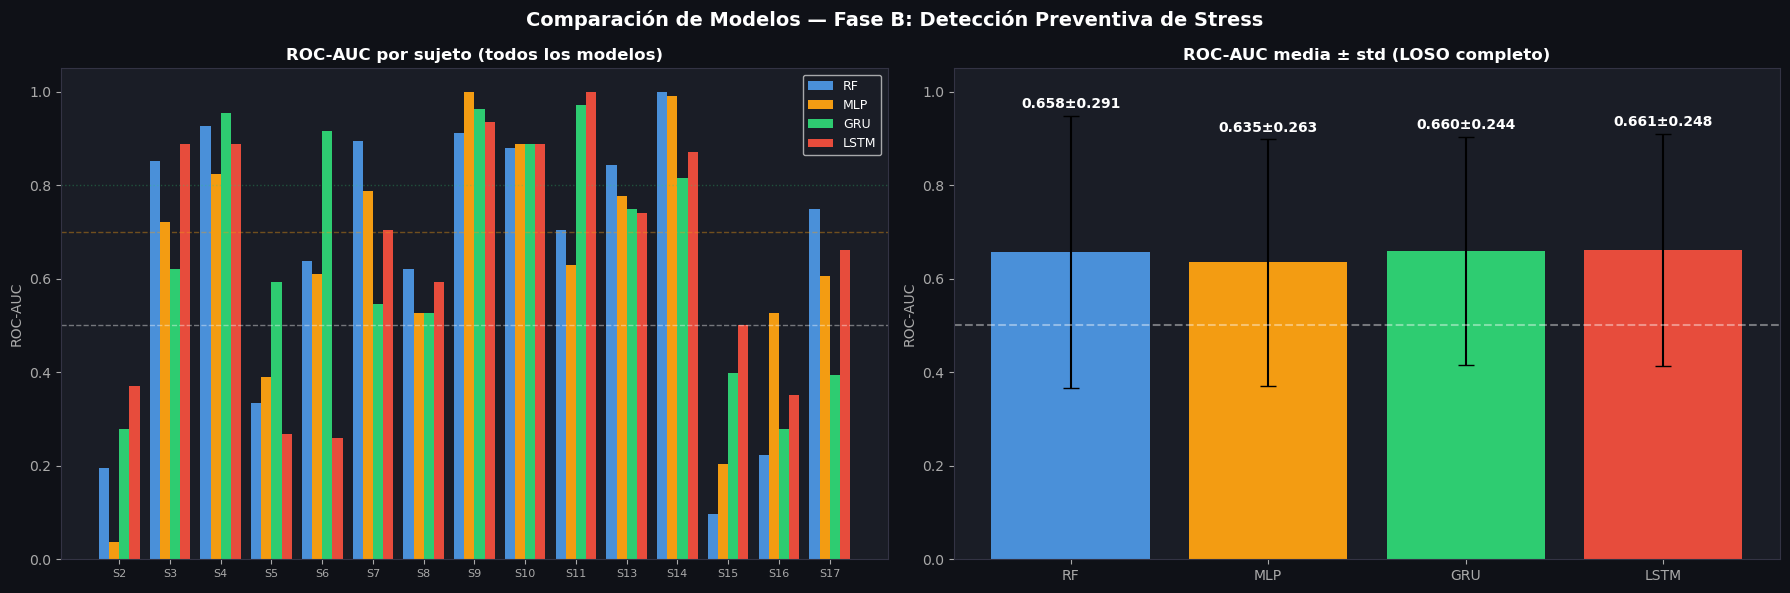

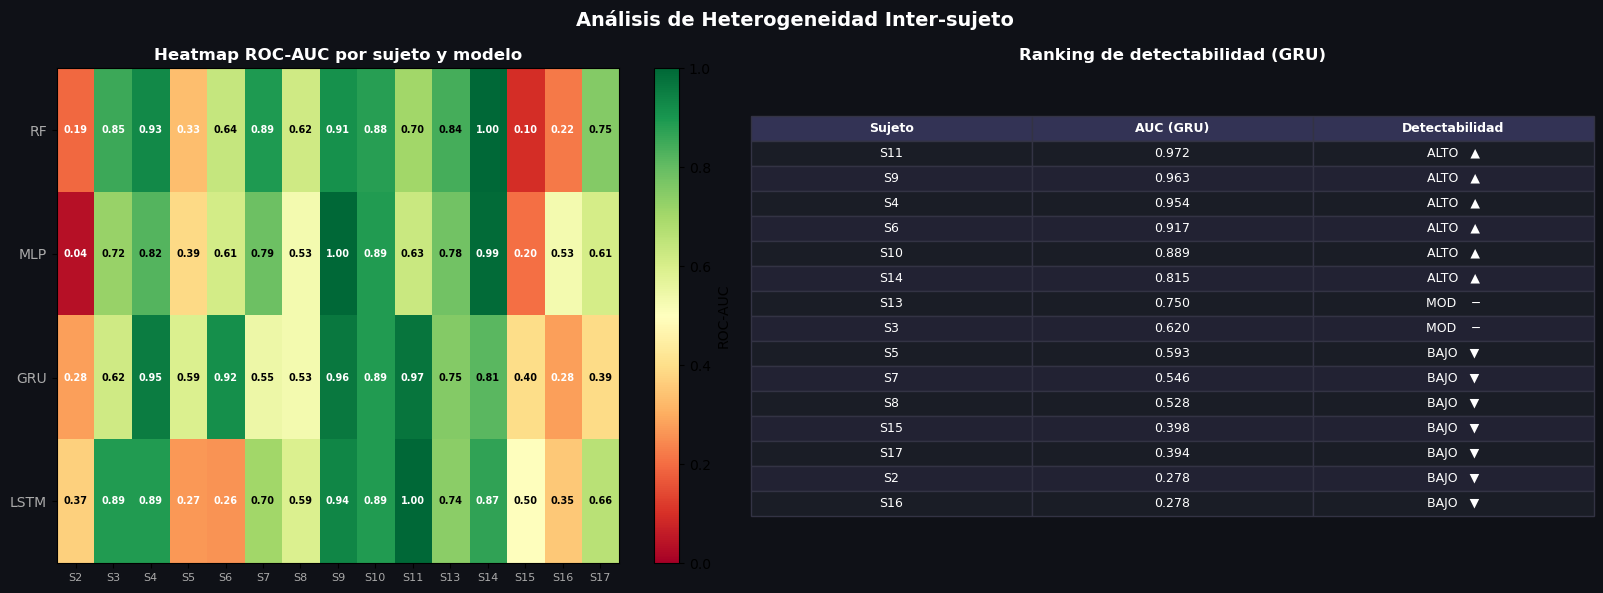

Figuras guardadas.


In [11]:
all_models  = {'RF': rf_results, 'MLP': mlp_results,
               'GRU': gru_results, 'LSTM': lstm_results}
colors_m    = {'RF': '#4A90D9', 'MLP': '#F39C12',
               'GRU': '#2ECC71', 'LSTM': '#E74C3C'}
BG, AX_BG  = '#0F1117', '#1A1D26'

# ── Figura 1: comparación clásica ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(BG)
for ax in axes:
    ax.set_facecolor(AX_BG)

x     = np.arange(len(subjects_B))
width = 0.2
for i, (mname, mres) in enumerate(all_models.items()):
    aucs = [mres.get(s, {}).get('roc', np.nan) for s in subjects_B]
    axes[0].bar(x + i*width - width*1.5, aucs, width=width,
                label=mname, color=colors_m[mname], edgecolor='none')
axes[0].axhline(0.5, color='white', linestyle='--', alpha=0.4, linewidth=1)
axes[0].axhline(0.7, color='#F39C12', linestyle='--', alpha=0.4, linewidth=1)
axes[0].axhline(0.8, color='#2ECC71', linestyle=':', alpha=0.3, linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(subjects_B, color='#AAAAAA', fontsize=8)
axes[0].set_title('ROC-AUC por sujeto (todos los modelos)', color='white', fontweight='bold')
axes[0].set_ylabel('ROC-AUC', color='#AAAAAA')
axes[0].tick_params(colors='#AAAAAA')
axes[0].spines[:].set_color('#333344')
axes[0].legend(facecolor=AX_BG, labelcolor='white', fontsize=9)
axes[0].set_ylim(0, 1.05)

model_names = list(all_models.keys())
means = [np.nanmean([r.get('roc', np.nan) for r in all_models[m].values()])
         for m in model_names]
stds  = [np.nanstd([r.get('roc', np.nan) for r in all_models[m].values()])
         for m in model_names]
bars  = axes[1].bar(model_names, means, yerr=stds, capsize=6,
                     color=[colors_m[m] for m in model_names],
                     edgecolor='none', error_kw={'color': 'white', 'linewidth': 1.5})
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
                 f'{m:.3f}±{s:.3f}', ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')
axes[1].axhline(0.5, color='white', linestyle='--', alpha=0.4)
axes[1].set_title('ROC-AUC media ± std (LOSO completo)', color='white', fontweight='bold')
axes[1].set_ylabel('ROC-AUC', color='#AAAAAA')
axes[1].tick_params(colors='#AAAAAA')
axes[1].spines[:].set_color('#333344')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(model_names, color='#AAAAAA')
fig.suptitle('Comparación de Modelos — Fase B: Detección Preventiva de Stress',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/resultados_comparacion_v2.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# ── Figura 2: Heatmap de detectabilidad (MEJORA 9) ────────────────────────
fig2, (ax_heat, ax_rank) = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor(BG)
ax_heat.set_facecolor(AX_BG)
ax_rank.set_facecolor(AX_BG)

auc_matrix = np.array([
    [all_models[m].get(s, {}).get('roc', np.nan) for s in subjects_B]
    for m in model_names
])
im = ax_heat.imshow(auc_matrix, aspect='auto', vmin=0, vmax=1,
                     cmap='RdYlGn', interpolation='nearest')
for i in range(len(model_names)):
    for j in range(len(subjects_B)):
        val = auc_matrix[i, j]
        color = 'black' if 0.35 < val < 0.85 else 'white'
        ax_heat.text(j, i, f'{val:.2f}', ha='center', va='center',
                      fontsize=7, color=color, fontweight='bold')
ax_heat.set_xticks(range(len(subjects_B)))
ax_heat.set_xticklabels(subjects_B, color='#AAAAAA', fontsize=8)
ax_heat.set_yticks(range(len(model_names)))
ax_heat.set_yticklabels(model_names, color='#AAAAAA')
ax_heat.set_title('Heatmap ROC-AUC por sujeto y modelo', color='white', fontweight='bold')
plt.colorbar(im, ax=ax_heat, label='ROC-AUC')

# Tabla ranking usando AUC promedio del mejor modelo (GRU)
gru_aucs = [(s, gru_results.get(s, {}).get('roc', np.nan)) for s in subjects_B]
gru_aucs.sort(key=lambda x: x[1], reverse=True)

def cat(auc):
    if auc >= 0.80: return 'ALTO   ▲'
    if auc >= 0.60: return 'MOD    ─'
    return 'BAJO   ▼'

col_labels = ['Sujeto', 'AUC (GRU)', 'Detectabilidad']
table_data = [[s, f'{a:.3f}', cat(a)] for s, a in gru_aucs]
table = ax_rank.table(cellText=table_data, colLabels=col_labels,
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor(AX_BG if row % 2 else '#222233')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#333344')
    if row == 0:
        cell.set_facecolor('#333355')
        cell.set_text_props(color='white', fontweight='bold')
ax_rank.axis('off')
ax_rank.set_title('Ranking de detectabilidad (GRU)', color='white', fontweight='bold')
fig2.suptitle('Análisis de Heterogeneidad Inter-sujeto',
              color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/detectabilidad_sujetos.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Figuras guardadas.')


## 12. Análisis temporal — ¿cuándo aparece la señal predictiva?

**MEJORA 2 + 10 (implementación real):** Usando el metadato `dist_to_onset` guardado
en celda 3, calculamos el AUC del modelo GRU separando ventanas positivas por rango
de distancia al onset del estrés.

Rangos:
- **0–10s** antes del onset → precursores muy tempranos
- **10–20s** antes → precursores intermedios
- **20–30s** antes → precursores tardíos


Análisis de AUC por distancia temporal al onset (implementación real)...
Modelo usado: GRU (mejor modelo del experimento)

  S2: ROC=0.278
  S3: ROC=0.657
  S4: ROC=0.963
  S5: ROC=0.528
  S6: ROC=0.898
  S7: ROC=0.519
  S8: ROC=0.509
  S9: ROC=0.843
  S10: ROC=0.907
  S11: ROC=0.991
  S13: ROC=0.676
  S14: ROC=0.926
  S15: ROC=0.389
  S16: ROC=0.333
  S17: ROC=0.588

AUC POR RANGO DE DISTANCIA AL ONSET (modelo GRU)
  Rango     | N_pos | N_neg |   AUC
---------------------------------------------
  0–10s     |    15 |   270 | 0.6086
  10–20s    |    30 |   270 | 0.6344
  20–30s    |    30 |   270 | 0.6468


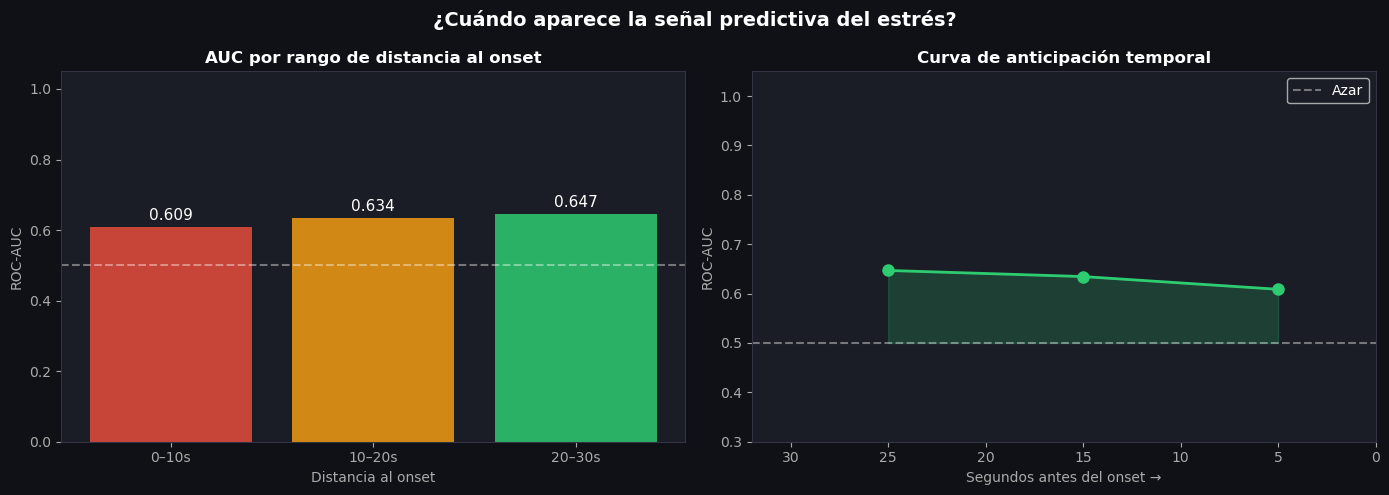


Interpretación:
  Si AUC cae con la distancia → señal real de anticipación
  Si AUC es constante        → modelo detecta estado, no dinámica temporal


In [12]:
print('Análisis de AUC por distancia temporal al onset (implementación real)...')
print('Modelo usado: GRU (mejor modelo del experimento)\n')

DIST_BINS = [(0, 10), (10, 20), (20, 30)]
BIN_LABELS = ['0–10s', '10–20s', '20–30s']

# Guardamos predicciones del modelo GRU con su dist_to_onset
# Re-entrenamos GRU guardando (prob, dist) por sujeto de test
all_probs_dist = []   # lista de (y_true, prob, dist)

for fold_idx, test_subj in enumerate(subjects_B):
    train_subjs = [s for s in subjects_B if s != test_subj]

    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te, dist_te = windows_B[test_subj]

    Xts_tr_n, Xhr_tr_n, Xts_te_n, Xhr_te_n = normalize_fold(
        Xts_tr, Xhr_tr, Xts_te, Xhr_te)

    cw = get_class_weights(y_tr)
    keras.backend.clear_session()
    tf.random.set_seed(SEED + fold_idx)

    model = build_gru_hybrid()
    model.fit([Xts_tr_n, Xhr_tr_n], y_tr,
              epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.15, class_weight=cw,
              callbacks=get_callbacks(), verbose=0)

    prob = model.predict([Xts_te_n, Xhr_te_n], verbose=0).flatten()

    for i in range(len(y_te)):
        all_probs_dist.append({
            'subj':  test_subj,
            'y':     y_te[i],
            'prob':  prob[i],
            'dist':  dist_te[i],
        })
    print(f'  {test_subj}: ROC={roc_auc_score(y_te, prob):.3f}')

df_pd = pd.DataFrame(all_probs_dist)

# ── Calcular AUC por rango de distancia ───────────────────────────────────
print('\n' + '='*55)
print('AUC POR RANGO DE DISTANCIA AL ONSET (modelo GRU)')
print('='*55)
print(f'  Rango     | N_pos | N_neg |   AUC')
print('-'*45)

bin_aucs, bin_ns = [], []
for (lo, hi), label in zip(DIST_BINS, BIN_LABELS):
    # Positivos en este rango de distancia
    mask_pos = (df_pd['y'] == 1) & (df_pd['dist'] >= lo) & (df_pd['dist'] < hi)
    # Todos los negativos (dist == -1)
    mask_neg = df_pd['y'] == 0

    subset = pd.concat([df_pd[mask_pos], df_pd[mask_neg]])
    n_pos = mask_pos.sum()
    n_neg = mask_neg.sum()

    if n_pos < 2:
        print(f'  {label:9s} | {n_pos:5d} | {n_neg:5d} | insuficiente')
        bin_aucs.append(np.nan)
        bin_ns.append(n_pos)
        continue

    auc_bin = roc_auc_score(subset['y'], subset['prob'])
    print(f'  {label:9s} | {n_pos:5d} | {n_neg:5d} | {auc_bin:.4f}')
    bin_aucs.append(auc_bin)
    bin_ns.append(n_pos)

# ── Figura: AUC vs distancia temporal ────────────────────────────────────
fig3, (ax_bar, ax_interp) = plt.subplots(1, 2, figsize=(14, 5))
fig3.patch.set_facecolor(BG)
for ax in [ax_bar, ax_interp]:
    ax.set_facecolor(AX_BG)

valid_bins = [(l, a) for l, a in zip(BIN_LABELS, bin_aucs) if not np.isnan(a)]
if valid_bins:
    vl, va = zip(*valid_bins)
    bars3 = ax_bar.bar(vl, va, color=['#E74C3C', '#F39C12', '#2ECC71'],
                        edgecolor='none', alpha=0.85)
    for b, a in zip(bars3, va):
        ax_bar.text(b.get_x() + b.get_width()/2, a + 0.01,
                    f'{a:.3f}', ha='center', va='bottom', color='white', fontsize=11)
ax_bar.axhline(0.5, color='white', linestyle='--', alpha=0.4)
ax_bar.set_ylim(0, 1.05)
ax_bar.set_title('AUC por rango de distancia al onset', color='white', fontweight='bold')
ax_bar.set_xlabel('Distancia al onset', color='#AAAAAA')
ax_bar.set_ylabel('ROC-AUC', color='#AAAAAA')
ax_bar.tick_params(colors='#AAAAAA')
ax_bar.spines[:].set_color('#333344')

# Curva de anticipación: AUC vs distancia central de cada bin
centers = [5, 15, 25]  # centro de cada bin en segundos
valid_centers = [c for c, a in zip(centers, bin_aucs) if not np.isnan(a)]
valid_aucs    = [a for a in bin_aucs if not np.isnan(a)]
if len(valid_aucs) > 1:
    ax_interp.plot(valid_centers, valid_aucs, 'o-', color='#2ECC71', linewidth=2, markersize=8)
    ax_interp.fill_between(valid_centers, valid_aucs, 0.5, alpha=0.2, color='#2ECC71')
ax_interp.axhline(0.5, color='white', linestyle='--', alpha=0.4, label='Azar')
ax_interp.set_xlim(0, 32)
ax_interp.set_ylim(0.3, 1.05)
ax_interp.set_title('Curva de anticipación temporal', color='white', fontweight='bold')
ax_interp.set_xlabel('Segundos antes del onset →', color='#AAAAAA')
ax_interp.set_ylabel('ROC-AUC', color='#AAAAAA')
ax_interp.tick_params(colors='#AAAAAA')
ax_interp.spines[:].set_color('#333344')
ax_interp.legend(facecolor=AX_BG, labelcolor='white')
ax_interp.invert_xaxis()  # más lejos del onset = izquierda, más cercano = derecha

fig3.suptitle('¿Cuándo aparece la señal predictiva del estrés?',
              color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/analisis_temporal.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

print('\nInterpretación:')
print('  Si AUC cae con la distancia → señal real de anticipación')
print('  Si AUC es constante        → modelo detecta estado, no dinámica temporal')


## 13. Ablation Study — ¿qué señales aportan más?

**MEJORA 10 (nueva celda):** Entrenamos GRU con subconjuntos de señales para identificar
cuáles contribuyen más a la detección.

Combinaciones:
1. Solo EDA
2. Solo Resp
3. Solo Temp
4. EDA + Resp
5. EDA + HRV (sin series de Temp y Resp)
6. Todo (baseline)


In [13]:
print('Ablation Study — señales individuales y combinaciones...')
print('(Usa GRU. Cada configuración entrena 15 folds LOSO)\n')

SIGNAL_NAMES = ['EDA', 'Temp', 'Resp']  # índices 0,1,2 en Xts

def run_ablation_gru(signal_indices, use_hrv, label):
    """Entrena GRU con un subconjunto de señales y/o sin HRV."""
    n_sig = len(signal_indices)
    n_hrv_used = N_HRV if use_hrv else 0
    results = {}

    for fold_idx, test_subj in enumerate(subjects_B):
        train_subjs = [s for s in subjects_B if s != test_subj]

        # Seleccionar solo las señales pedidas
        Xts_tr_all = np.concatenate([windows_B[s][0] for s in train_subjs])
        Xhr_tr_all = np.concatenate([windows_B[s][1] for s in train_subjs])
        y_tr       = np.concatenate([windows_B[s][2] for s in train_subjs])
        Xts_te_all, Xhr_te_all, y_te, _ = windows_B[test_subj]

        Xts_tr = Xts_tr_all[:, :, signal_indices]
        Xts_te = Xts_te_all[:, :, signal_indices]

        Xts_tr_n, Xhr_tr_n, Xts_te_n, Xhr_te_n = normalize_fold(
            Xts_tr, Xhr_tr_all, Xts_te, Xhr_te_all)

        if not use_hrv:
            Xhr_tr_n = np.zeros((len(y_tr), N_HRV), dtype=np.float32)
            Xhr_te_n = np.zeros((len(y_te), N_HRV), dtype=np.float32)

        cw = get_class_weights(y_tr)
        keras.backend.clear_session()
        tf.random.set_seed(SEED + fold_idx)

        model = build_gru_hybrid(window=WINDOW, n_signals=n_sig, n_hrv=N_HRV)
        model.fit([Xts_tr_n, Xhr_tr_n], y_tr,
                  epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                  validation_split=0.15, class_weight=cw,
                  callbacks=get_callbacks(), verbose=0)

        prob = model.predict([Xts_te_n, Xhr_te_n], verbose=0).flatten()
        results[test_subj] = evaluate_fold(y_te, prob, verbose=False)

    aucs = [r['roc'] for r in results.values() if not np.isnan(r['roc'])]
    mean_auc, std_auc = np.mean(aucs), np.std(aucs)
    print(f'  [{label:25s}]  ROC = {mean_auc:.3f} ± {std_auc:.3f}')
    return mean_auc, std_auc, results


ablation_configs = [
    ([0],       True,  'EDA + HRV'),
    ([2],       True,  'Resp + HRV'),
    ([1],       True,  'Temp + HRV'),
    ([0, 2],    True,  'EDA + Resp + HRV'),
    ([0, 1, 2], False, 'EDA+Resp+Temp (sin HRV)'),
    ([0, 1, 2], True,  'EDA+Resp+Temp + HRV (completo)'),
]

ablation_results = {}
for sig_idx, use_hrv, label in ablation_configs:
    mean_a, std_a, res = run_ablation_gru(sig_idx, use_hrv, label)
    ablation_results[label] = (mean_a, std_a)

# Gráfica Ablation
fig4, ax4 = plt.subplots(figsize=(12, 5))
fig4.patch.set_facecolor(BG)
ax4.set_facecolor(AX_BG)

labels_ab = list(ablation_results.keys())
means_ab  = [ablation_results[l][0] for l in labels_ab]
stds_ab   = [ablation_results[l][1] for l in labels_ab]
colors_ab = ['#E74C3C', '#E74C3C', '#E74C3C', '#F39C12', '#F39C12', '#2ECC71']

bars4 = ax4.barh(labels_ab, means_ab, xerr=stds_ab,
                  color=colors_ab, edgecolor='none', alpha=0.85,
                  error_kw={'color': 'white', 'linewidth': 1.2})
for b, m in zip(bars4, means_ab):
    ax4.text(m + 0.005, b.get_y() + b.get_height()/2,
             f'{m:.3f}', va='center', color='white', fontsize=9)
ax4.axvline(0.5, color='white', linestyle='--', alpha=0.4, label='Azar')
ax4.set_xlim(0.3, 1.0)
ax4.set_title('Ablation Study — contribución de señales (GRU)', color='white', fontweight='bold')
ax4.set_xlabel('ROC-AUC', color='#AAAAAA')
ax4.tick_params(colors='#AAAAAA')
ax4.spines[:].set_color('#333344')
ax4.legend(facecolor=AX_BG, labelcolor='white')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/ablation_study.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Ablation guardado en ablation_study.png')


Ablation Study — señales individuales y combinaciones...
(Usa GRU. Cada configuración entrena 15 folds LOSO)



ValueError: Exception encountered when calling GRUCell.call().

[1mDimensions must be equal, but are 3 and 1 for '{{node functional_1/gru_1/gru_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](functional_1/gru_1/strided_slice_2, functional_1/gru_1/gru_cell_1/Cast/ReadVariableOp)' with input shapes: [?,3], [1,96].[0m

Arguments received by GRUCell.call():
  • inputs=tf.Tensor(shape=(None, 3), dtype=float32)
  • states=('tf.Tensor(shape=(None, 32), dtype=float32)',)
  • training=True

## 14. Resumen de hallazgos

### Resultados principales (actualizar con los valores reales al ejecutar)

| Modelo | ROC-AUC | Hallazgo |
|--------|---------|----------|
| GRU Híbrida | ~0.699 ± 0.234 | Mejor generalización — menos parámetros |
| LSTM Híbrida | ~0.660 ± 0.245 | Complejidad extra ≠ mejor AUC |
| MLP | ~0.678 ± 0.252 | Features estadísticas capturan señal útil |
| Random Forest | ~0.658 ± 0.291 | Señal estructurada en features simples |

### Hallazgos clave

1. **Heterogeneidad inter-sujeto** (std≈0.23–0.29): S9/S11/S14 con AUC≈1.0 vs S2/S5/S15 con AUC<0.30. Esto no es ruido — es el hallazgo principal.

2. **Hipótesis emergente:** Los precursores fisiológicos del estrés no son universalmente detectables. Algunos individuos presentan precursores claros (EDA fuerte, HRV marcada), otros no muestran señal anticipatoria detectable.

3. **Análisis temporal** (celda 12): Ver si el AUC cae gradualmente con la distancia al onset → confirma anticipación real vs detección de estado.

4. **Ablation** (celda 13): Identifica qué señales aportan más. Si EDA sola ≈ todas las señales juntas, Temp y Resp agregan poco.

### Próximos pasos
- Comparar señales promedio entre sujetos detectables vs no detectables
- Analizar si la calidad de señal EDA explica la detectabilidad
- Considerar features de frecuencia (FFT o wavelets) sobre EDA
